In [1]:
import numpy as np                 # εισάγουμε τη βιβλιοθήκη numpy και θα τη "φωνάζουμε" np
import matplotlib.pyplot as plt    # εισάγουμε τη συνάρτηση pyplot της βιβλιοθήκης matplotlib και θα τη "φωνάζουμε" plt
from IPython.display import Audio   

## Άσκηση - Σήματα Chirp

Σε προηγούμενα Κεφάλαια - αλλά και σε αυτό - αυτό μιλήσαμε αρκετά για τα ημιτονοειδή σήματα, το πλάτος, τη συχνότητα, και την αρχική φάση τους. Η γενική έκφραση που χρησιμοποιήσαμε ήταν η

$$ x(t) = A\cos(2\pi f_0 t + \phi)$$

με $A, f_0, \phi$ το πλάτος, η συχνότητα, και η φάση αντίστοιχα. 

Κάθε ημιτονοειδές τέτοιας μορφής έχει σταθερή συχνότητα ίση με $f_0$ Hz. Ας ακούσουμε ένα τέτοιο ημιτονοειδές συχνότητας $500$ Hz.

In [ ]:
fs = 16000                         # συχνότητα δειγματοληψίας - θα μάθετε αργότερα γι'αυτήν
f0 = 500                           # συχνότητα

t = np.arange(0, 2, 1/fs)          # άξονας χρόνου 2 δευτερολέπτων με βήμα 1/fs (δηλαδή 1/16000)
output = np.cos(2*np.pi*f0*t)      # ημιτονοειδές !

Audio(output, rate=fs)             # ακούστε! :)

Μιλώντας λίγο πιο τεχνικά, η **στιγμιαία** συχνότητα αποτελεί την πρώτη παράγωγο του ορίσματος ενός ημιτονοειδούς σήματος, με βάση τη σχέση

$$ f(t) = \frac{1}{2\pi}\frac{d}{dt}\Phi(t) $$

με $\Phi(t)$ τη **συνολική φάση** του ημιτονοειδούς, δηλ. στην περίπτωση που μελετάμε παραπάνω 

$$\Phi(t) = 2\pi f_0 t + \phi \Longrightarrow f(t) = \frac{1}{2\pi}\frac{d}{dt}(2\pi f_0 t + \phi) = f_0$$

Βλέπετε ότι στην περίπτωση μας, η στιγμιαία συχνότητα είναι σταθερή και ταυτίζεται με την $f_0$. Τι συμβαίνει όμως αν ένα ημιτονοειδές **δεν** έχει σταθερή συχνότητα? 

Ας δούμε εδώ ένα τέτοιο παράδειγμα.

(α') Τα **chirp σήματα** είναι σήματα στα οποία η συχνότητα αυξάνεται ή μειώνεται µε την πάροδο του χρόνου. Τέτοια σήματα έχουν εφαρμογές σε συστήματα radar και sonar, και σε τηλεπικοινωνιακά συστήματα. Θέλουμε να δημιουργήσουμε ένα chirp σήμα το οποίο θα έχει **γραμμικά** αυξανόμενη στιγμιαία συχνότητα $f(t)$, ξεκινώντας από τα $f_{\text{begin}} = 100$ Hz και φτάνοντας στα $f_{\text{end}} = 2000$ Hz. Θέλουμε η αύξηση αυτή να γίνεται μέσα σε χρόνο $t = 4$ δευτερόλεπτα, ξεκινώντας από $t = 0$. 

Με άλλα λόγια, θέλουμε μια "καμπύλη" συχνότητας που σε ένα νοητό χώρο (χρόνου, συχνότητας) να ξεκινά από το σημείο $(0, 100)$ και να καταλήξει στο σημείο $(4, 2000)$. Η εξίσωση μιας τέτοιας ευθείας, δηλ. που περνά από δυο γνωστά σημεία $(x_0, y_0)$, $(x_1, y_1)$ - μας είναι γνωστή από τα μαθηματικά:

$$y-y_0 = \frac{y_1-y_0}{x_1-x_0}(x-x_0)$$

και στην περίπτωσή μας θα είναι 

$$f(t) - 100 = \frac{2000-100}{4-0}(t-0) \Longleftrightarrow f(t) = 100 + \frac{1900}{4}t = 100 + 475t$$

Ας τη σχεδιάσουμε:

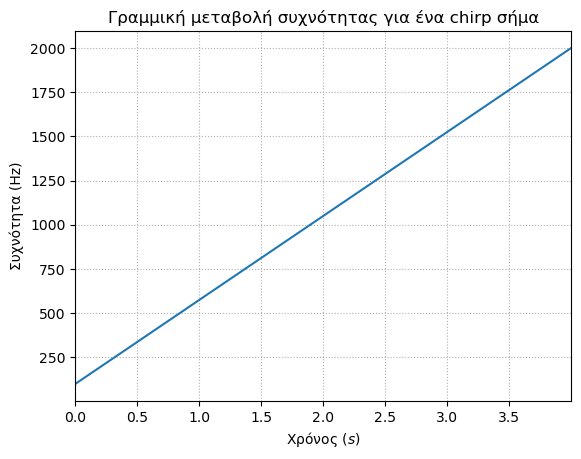

In [3]:
fs = 16000                      # συχνότητα δειγματοληψίας - θα μάθετε αργότερα γι'αυτήν
t = np.arange(0, 4, 1/fs)       # άξονας χρόνου
f = 100 + 475*t                 # στιγμιαία συχνότητα

plt.figure()                    # σχήμα
plt.plot(t, f)                  # γράφημα
plt.grid(linestyle=':')         # ομορφαίνουμε
plt.xlabel('Χρόνος $(s)$')      # --- || ----
plt.ylabel('Συχνότητα (Hz)')    # --- || ----
plt.title('Γραμμική μεταβολή συχνότητας για ένα chirp σήμα') # --- || ----
plt.xlim([min(t), max(t)])      # --- || ----
plt.show()                      # --- || ----

Για να την ακούσουμε, πρέπει να τη "φορτώσουμε" στη **συνολική φάση** $\Phi(t)$ σε ένα ημιτονοειδές, με τέτοιο τρόπο ώστε αν παραγωγίσουμε αυτή τη **συνολική** του φάση να πάρουμε ακριβώς τη στιγμιαία συχνότητα που βρήκαμε παραπάνω.

Με άλλα λόγια, χρειαζόμαστε η συνολική φάση $\Phi(t)$ να είναι

$$\Phi(t) = 2\pi \int_0^t f(u)du$$

έτσι ώστε πράγματι

$$f(t) = \frac{1}{2\pi}\frac{d}{dt}\Phi(t)$$

Στο παράδειγμά μας, η συνολική φάση $\Phi(t)$ θα είναι

\begin{align*}
    \Phi(t) &= 2\pi \int_0^t f(u) du \\
    &= 2\pi \int_0^t (100 + 475u) du \\
    &= 2\pi \left(100u + 475 \frac{u^2}{2}\right)\Big|_{u=0}^{u=t} \\
    &= 2\pi \left(100t + 475\frac{t^2}{2}\right) \\
    &= 2\pi 100t + 475\pi t^2
\end{align*}

για $0 < t < 4$ δευτερόλεπτα. Αυτή θα είναι η συχνολική φάση του ημιτονοειδούς μας! 😃 Προγραμματίστε και ακούστε την στο παρακάτω κελί κώδικα.

In [ ]:
fs = 16000                         # συχνότητα δειγματοληψίας - θα μάθετε αργότερα γι'αυτήντ
t = np.arange(0, 4, 1/fs)          # άξονας χρόνου 4 δευτερολέπτων με βήμα 1/fs (δηλαδή 1/16000)

Phi = 2*np.pi*100*(t) + 475*np.pi*(t)**2   # συνολική φάση!

output = np.cos(Phi)               # ημιτονοειδές
Audio(output, rate=fs)             # ακούστε! :)

(β') Έστω ότι τώρα θέλουμε να δημιουργήσουμε ένα chirp σήμα που θα έχει **πολυωνυμικά** αυξανόμενη συχνότητα, και συγκεκριμένα µε παραβολική αύξηση, ξανά σε διάστημα $t = 4$ δευτερολέπτων! 

Για την κατασκευή της συνάρτησης στιγμιαίας συχνότητας $f(t)$ θα χρειαστείτε τρία σημεία: ας υποθέσουμε ότι αυτά είναι τα

$$(t_i, f_i) = (0,200), (2,1000), (4,4000), \: \: i=1,2,3$$

µε την πρώτη τιμή κάθε ζεύγους να δηλώνει το χρόνο σε δευτερόλεπτα, και τη δεύτερη τιμή να δηλώνει την τιμή της στιγμιαίας συχνότητας σε Hz. Άρα από τα παραπάνω σημεία συμπεραίνουμε ότι η στιγμιαία συχνότητα ξεκινά από τα $200$ Hz για $t = 0$, φτάνει τα $1000$ Hz όταν $t = 2$, και καταλήγει στα $4000$ Hz για $t = 4$. Υπενθυμίζεται ότι µια παραβολή είναι της μορφής

$$f(t) = a + bt + ct^2$$

(i) Βρείτε τους αγνώστους $a, b, c$ λύνοντας το σύστημα που προκύπτει από τη γνώση των σημείων $(t_i, f_i)$ σε ένα χαρτί, και γράψτε την εξίσωση της στιγμιαίας συχνότητας $f(t)$. Σχεδιάστε την όπως πριν.

(ii) Υπολογίστε τη φάση $\Phi(t)$ ολοκληρώνοντάς την $f(t)$ όπως στο προηγούμενο παράδειγμα.

(iii) Γράψτε το ημιτονοειδές σήμα στο χρόνο $x(t)$ που τελικά προκύπτει. Αν όλα πάνε καλά, θα πρέπει να βρείτε

$$x(t) = \cos\left(2\pi\left(\frac{275}{3}t^3 - 75t^2 + 200t\right)\right)$$

(iv) Ακούστε αυτό το σήμα.

Ακολουθήστε τον παρακάτω σκελετό για τα ερωτήματα αυτά.

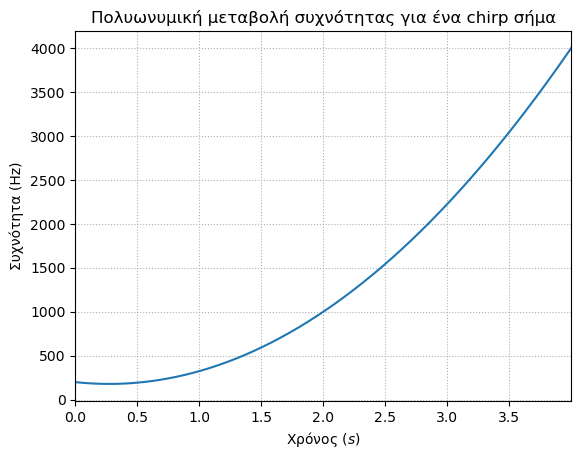

In [5]:
# (i)
a = 200
b = -150
c = 275

t = np.arange(0, 4, 1/fs)       # άξονας χρόνου
f = a + b*t + c*t**2            # στιγμιαία συχνότητα

plt.figure()                    # σχήμα
plt.plot(t, f)                  # γράφημα
plt.grid(linestyle=':')         # ομορφαίνουμε
plt.xlabel('Χρόνος $(s)$')      # --- || ----
plt.ylabel('Συχνότητα (Hz)')    # --- || ----
plt.title('Πολυωνυμική μεταβολή συχνότητας για ένα chirp σήμα') # --- || ----
plt.xlim([min(t), max(t)])      # --- || ----
plt.show()                      # --- || ----

In [9]:
fs = 16000                      # συχνότητα δειγματοληψίας
t = np.arange(0, 4, 1/fs)       # άξονας χρόνου (4 δευτερόλεπτα)

# (ii)
Phi = 2*np.pi*(275/3*(t)**3 - 75*(t)**2 + 200*(t))           # συνολική φάση!

# (iii)
x = np.cos(Phi)                 # ημιτονοειδές

# (iv)
Audio(x, rate=fs)               # ακούστε! :)

(γ') Τι θα κάνετε αν σας ζητούσαν μια μεταβολή συχνότητας που να ακολουθεί ένα πολυώνυμο ΔΕΚΑΤΟΥ (10ου) βαθμού; Εξηγήστε (ΧΩΡΙΣ ΚΩΔΙΚΑ, μόνο περιγραφικά)

### Απάντηση:

Θα χρειαζόμουν $11$ (!!) σημεία $(t_i, f_i)$ και θα έπρεπε με κάποιο τρόπο να τα ταιριάξω σε ένα πολυώνυμο 10ου βαθμού της μορφής $a + bt + ct^2 + dt^3 + ... + kt^{10}$ ώστε να βρω τους αγνώστους συντελεστές. Μετά θα ολοκλήρωνα αυτό το πολυώνυμο αυτό για να βρω τη συνολική φάση και να την δώσω σε ένα συνημίτονο.

---
---